In [1]:
import requests #per poter cercare su internet
import os #per creare il file in locale con i dati presi da internet
import pandas as pd #per analizzare i dati
import numpy as np #aggiunta in seguito per modificare le colonne / rinominare / pivottare

#per la Regressione / clustering 
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#recupero dati

url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
header = {"Accept": "application/vnd.sdmx.data+csv;version=1.0.0"}

if not os.path.exists("raw_data.csv"):
    raw_data = requests.get(url, headers=header)
    #scrittura del file in locale
    with open("raw_data.csv", "w", encoding="utf-8") as f:
        f.write(raw_data.text)





    

In [3]:
#do un'occhiata ai dati sporchi 

raw_df = pd.read_csv( "raw_data.csv")
raw_df.head()

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
kept_columns = ["REF_AREA","DATA_TYPE","RESULT","TIME_PERIOD","OBS_VALUE"]
df = raw_df[kept_columns]
df.head()

#ho rimosso le colonne con "NaN" perché vuote e ho tenuto i dettagli che penso possano essere rilevanit per la mia analisi

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
0,1001,KILLINJ,F,2001,10
1,1001,KILLINJ,F,2002,10
2,1001,KILLINJ,F,2003,7
3,1001,KILLINJ,F,2004,13
4,1001,KILLINJ,F,2005,2


Ora controllo il tipo di dati, per evitare che il testo abbia type integer o che i numeri abbiamo type string e controllo se sono rimasti valori nulli

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   REF_AREA     573552 non-null  int64
 1   DATA_TYPE    573552 non-null  str  
 2   RESULT       573552 non-null  str  
 3   TIME_PERIOD  573552 non-null  int64
 4   OBS_VALUE    573552 non-null  int64
dtypes: int64(3), str(2)
memory usage: 21.9 MB


In [6]:
#opzionale, perché già dalle info vedo non-null.
#posso runnare queste righe individualmente per fare un doppio check e vedere se appaiono valori null

df[df["REF_AREA"].isnull()]
df[df["DATA_TYPE"].isnull()]
df[df["RESULT"].isnull()]
df[df["TIME_PERIOD"].isnull()]
df[df["OBS_VALUE"].isnull()]


,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE


In [7]:
#voglio vedere che tipi di incidenti ci sono

df["DATA_TYPE"].value_counts()

#noto che ci sono più morti/feriti che incidenti (il doppio). Questa cosa non ha senso, perché se rimaniamo nell'ambito stradale, per esserci un morto o un ferito dev'esserci un incidente

DATA_TYPE
KILLINJ    382368
ROADACC    191184
Name: count, dtype: int64

In [8]:
df["RESULT"].value_counts()

#anche qui il count dei valori per categoria di incidente è strano; c'è lo stesso numero di righe per ogni tipo di RESULT
#questo mi fa sospettare che ogni anno, per ogni comune nel df si crei comunque una riga per ciascun tipo di RESULT, e in OBS_VALUE si inserisca 0 in corrispondenza di F se in quell'anno e in quel comune non ci sono stati incidenti con feriti.
#siccome sto facendo una count, anche le righe con 0 su OBS_VALUE vengono contate
#Ho controllato su Excel importando il CSV ed effettivamente è così

RESULT
F    191184
M    191184
9    191184
Name: count, dtype: int64

Inoltre, facendo una ricerca sul web, vedo che F sta per Feriti e M per Morti -- ha senso se consideriamo che l'ISTAT è un ente italiano (anche le colonne sono in inglese -- template preso da qualche altro ente?)

In [9]:
print(df.groupby("RESULT")["OBS_VALUE"].sum())
#faccio una groupby per RESULT con somma OBS_VALUE per vedere se la mia teoria è corretta, e gli incidenti con feriti sono molti di più di quelli con morti. Ha senso
# 9, con una ricerca su internet, equivale al "non applicable" per l'ISTAT, quindi non lo considererò

RESULT
9    4779141
F    6709026
M     101944
Name: OBS_VALUE, dtype: int64


Ora procedo a fare il merge con l'altro dataset, quello di SITUAS 
Prima però controllo il datatype delle singole colonne:

In [10]:
situas_local_file = "SITUAS_2024.csv"

situas_df = pd.read_csv(situas_local_file, sep=';', encoding='latin1')
situas_df.head()

,ï»¿Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,1,1,1,201,1001,1001,AgliÃ¨,NaN,TO,0,0,2562,2021,"13,1463",2024,2585,2024
1,1,1,1,201,1002,1002,Airasca,NaN,TO,0,0,3660,2021,"15,7393",2024,3695,2024
2,1,1,1,201,1003,1003,Ala di Stura,NaN,TO,0,0,467,2021,"46,3316",2024,463,2024
3,1,1,1,201,1004,1004,Albiano d'Ivrea,NaN,TO,0,0,1637,2021,"11,7397",2024,1624,2024
4,1,1,1,201,1006,1006,Almese,NaN,TO,0,0,6331,2021,"17,8741",2024,6297,2024


In [11]:
situas_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7896 entries, 0 to 7895
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   ï»¿Codice Ripartizione geografica  7896 non-null   int64
 1   Codice Regione                     7896 non-null   int64
 2   Codice Provincia (Storico)         7896 non-null   int64
 3   Codice Provincia/Uts               7896 non-null   int64
 4   Codice Comune (alfanumerico)       7896 non-null   int64
 5   Codice Comune (numerico)           7896 non-null   int64
 6   Comune                             7895 non-null   str  
 7   Comune (dizione straniera)         124 non-null    str  
 8   Sigla automobilistica              7804 non-null   str  
 9   Capoluogo di Provincia/Uts         7896 non-null   int64
 10  Capoluogo di Regione               7896 non-null   int64
 11  Popolazione legale                 7896 non-null   int64
 12  Anno Censimento                

noto che Superficie (Kmq) è una stringa, il che non va bene. Cercando su internet, scopro che è un problema per python perché la virgola viene considerata separatore decimale, e non delle migliaia

Devo sostituirlo

In [12]:
situas_clean = situas_df[["Codice Comune (numerico)", "Comune", "Superficie (Kmq)", "Popolazione residente"]].copy()

situas_clean["Superficie (Kmq)"] = (
        situas_clean["Superficie (Kmq)"].astype(str).str.replace(".","", regex =False)
        .str.replace(",",".", regex =False).astype(float))

situas_clean.info()

#ho tolto i punti e rimpazzato le virgole con i punti
#regex false per evitare che mi cancelli tutti i dati considerando i punti come "qualsiasi carattere"

<class 'pandas.DataFrame'>
RangeIndex: 7896 entries, 0 to 7895
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Codice Comune (numerico)  7896 non-null   int64  
 1   Comune                    7895 non-null   str    
 2   Superficie (Kmq)          7896 non-null   float64
 3   Popolazione residente     7896 non-null   int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 246.9 KB


Per la Join, devo unire REF_AREA con Codice Comune (numerico) visto che hanno entrambi il type int64



In [13]:
situas_df["Codice Comune (numerico)"].dtype

dtype('int64')

In [14]:
merge_dfs = df.merge(
    situas_clean,
    left_on="REF_AREA",
    right_on="Codice Comune (numerico)",
    how="inner"
)

merge_dfs.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Comune (numerico),Comune,Superficie (Kmq),Popolazione residente
0,1001,KILLINJ,F,2001,10,1001,AgliÃ¨,13.1463,2585
1,1001,KILLINJ,F,2002,10,1001,AgliÃ¨,13.1463,2585
2,1001,KILLINJ,F,2003,7,1001,AgliÃ¨,13.1463,2585
3,1001,KILLINJ,F,2004,13,1001,AgliÃ¨,13.1463,2585
4,1001,KILLINJ,F,2005,2,1001,AgliÃ¨,13.1463,2585


In [15]:
#merge fatta, tolgo la colonna duplicata del codice area / comune

merge_dfs.drop(columns=["Codice Comune (numerico)"], inplace=True)
merge_dfs.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Comune,Superficie (Kmq),Popolazione residente
0,1001,KILLINJ,F,2001,10,AgliÃ¨,13.1463,2585
1,1001,KILLINJ,F,2002,10,AgliÃ¨,13.1463,2585
2,1001,KILLINJ,F,2003,7,AgliÃ¨,13.1463,2585
3,1001,KILLINJ,F,2004,13,AgliÃ¨,13.1463,2585
4,1001,KILLINJ,F,2005,2,AgliÃ¨,13.1463,2585


In [16]:
rename_columns = {
    "REF_AREA": "Codice_comune",
    "DATA_TYPE": "Tipo_dato",
    "RESULT" : "Codice_esito",
    "TIME_PERIOD": "Anno",
    "OBS_VALUE": "Numero_eventi",
    "Superficie (Kmq)": "Superficie_Kmq",
    "Popolazione residente": "Popolazione_residente"


}

merge_dfs.rename(columns=rename_columns, inplace=True)

merge_dfs.head()

,Codice_comune,Tipo_dato,Codice_esito,Anno,Numero_eventi,Comune,Superficie_Kmq,Popolazione_residente
0,1001,KILLINJ,F,2001,10,AgliÃ¨,13.1463,2585
1,1001,KILLINJ,F,2002,10,AgliÃ¨,13.1463,2585
2,1001,KILLINJ,F,2003,7,AgliÃ¨,13.1463,2585
3,1001,KILLINJ,F,2004,13,AgliÃ¨,13.1463,2585
4,1001,KILLINJ,F,2005,2,AgliÃ¨,13.1463,2585


In [17]:
#Siccome nel tipo_dato ci sono sia KILLINJ che ROADACC e si intrecciano (perché un incidente può avere morti, non possono essere considerati separatamente),
# modifico la struttura affinché io abbia le due tipologie di dato su colonne diverse, non righe


merge_dfs_2024 = merge_dfs[merge_dfs["Anno"] == 2024]

pivot = merge_dfs_2024.pivot_table(
    index=["Codice_comune", "Comune", "Anno", "Superficie_Kmq", "Popolazione_residente"],
    columns="Tipo_dato",
    values="Numero_eventi",
    aggfunc="sum"
).reset_index()

pivot.rename(columns={"ROADACC": "Incidenti", "KILLINJ": "Morti_Feriti"}, inplace=True)

pivot.head()


Tipo_dato,Codice_comune,Comune,Anno,Superficie_Kmq,Popolazione_residente,Morti_Feriti,Incidenti
0,1001,AgliÃ¨,2024,13.1463,2585,5,2
1,1002,Airasca,2024,15.7393,3695,9,5
2,1003,Ala di Stura,2024,46.3316,463,2,1
3,1004,Albiano d'Ivrea,2024,11.7397,1624,9,4
4,1006,Almese,2024,17.8741,6297,2,2


In [18]:
pivot.describe()

Tipo_dato,Codice_comune,Anno,Superficie_Kmq,Popolazione_residente,Morti_Feriti,Incidenti
count,6338.000000,6338.0,6338.000000,6.338000e+03,6338.000000,6338.000000
mean,45089.239034,2024.0,41.708021,9.094797e+03,37.373935,27.352319
std,31886.744280,0.0,54.922311,4.622177e+04,285.120762,226.883113
min,1001.000000,2024.0,0.122200,4.700000e+01,1.000000,1.000000
25%,17051.250000,2024.0,12.374150,1.523250e+03,3.000000,2.000000
50%,38020.500000,2024.0,24.235900,3.350500e+03,8.000000,6.000000
75%,71048.500000,2024.0,48.520075,7.771250e+03,23.000000,16.000000
max,111107.000000,2024.0,1288.187500,2.747290e+06,17330.000000,13924.000000


In [19]:
#trovo e sistemo i nomi dei comuni con le lettere accentate non riconosciute dall'encoding

comuni_anomali =pivot[pivot["Comune"].str.contains(r"[ÃÂ]", na=False)]["Comune"].unique()
print(comuni_anomali)

<StringArray>
[                'AgliÃ¨',                 'CiriÃ¨',               'CuorgnÃ¨',
              'LusigliÃ¨',              'VestignÃ¨',                   'ViÃ¹',
                'BianzÃ¨',               'SanthiÃ ',        'Bastia MondovÃ¬',
                 'CardÃ¨',
 ...
 'San NicolÃ² d'Arcidano',              'CavagliÃ ',               'BarzanÃ²',
       'Santa Maria HoÃ¨',                  'CirÃ²',           'CirÃ² Marina',
                  'DasÃ ',                'MuggiÃ²',     'San NicolÃ² Gerrei',
               'SenorbÃ¬']
Length: 133, dtype: str


In [20]:
correct_locs = {
    "Ã¨": "è",
    "Ã©": "é",
    "Ã": "à",
    "Ã²": "ò",
    "Ã¹": "ù",
    "Ã¬": "ì"
}

for broken, fixed in correct_locs.items():
    pivot["Comune"] = pivot["Comune"].str.replace(broken, fixed, regex=False)

comuni_anomali = pivot[pivot["Comune"].str.contains("[ÃÂ]", na=False)]["Comune"].unique()
    
print(len(comuni_anomali))

0


Aggiungo i KPI che reputo possano servirmi

In [21]:
#Incidenti ogni 1000 abitanti
pivot["Accidents_per_1k_residents"] = ((pivot["Incidenti"] / pivot["Popolazione_residente"]) * 1000).round(2)

#Incidenti per km2
pivot["Accidents_per_kmsq"] = (pivot["Incidenti"] / pivot["Superficie_Kmq"]).round(2)

#Severity
pivot["Severity"] = np.where(pivot["Incidenti"] == 0, 0, pivot["Morti_Feriti"] / pivot["Incidenti"]) #evito che vengano considerati per il calcolo i comuni in cui non ci sono incidenti
pivot["Severity"] = pivot["Severity"].round(2)


pivot.head()

Tipo_dato,Codice_comune,Comune,Anno,Superficie_Kmq,Popolazione_residente,Morti_Feriti,Incidenti,Accidents_per_1k_residents,Accidents_per_kmsq,Severity
0,1001,Agliè,2024,13.1463,2585,5,2,0.77,0.15,2.50
1,1002,Airasca,2024,15.7393,3695,9,5,1.35,0.32,1.80
2,1003,Ala di Stura,2024,46.3316,463,2,1,2.16,0.02,2.00
3,1004,Albiano d'Ivrea,2024,11.7397,1624,9,4,2.46,0.34,2.25
4,1006,Almese,2024,17.8741,6297,2,2,0.32,0.11,1.00


In [22]:
# I comuni con pochissimi abitanti creano problemi per quanto riguarda i KPI, in quanto bastano pochi incidenti per far schizzare il piccolo comune in cima alla classifica
# Devo identificarli ed escluderli
# Escludo i comuni con meno di 10k abitanti: non ci sono opportunità di investimenti importanti nella maggior parte dei casi
# Rimuovo anche i comuni con 0 incidenti

pivot[["Incidenti", "Popolazione_residente", "Superficie_Kmq", "Accidents_per_1k_residents", "Accidents_per_kmsq"]].describe()



Tipo_dato,Incidenti,Popolazione_residente,Superficie_Kmq,Accidents_per_1k_residents,Accidents_per_kmsq
count,6338.000000,6.338000e+03,6338.000000,6338.000000,6338.000000
mean,27.352319,9.094797e+03,41.708021,2.316128,0.807080
std,226.883113,4.622177e+04,54.922311,1.940898,1.858371
min,1.000000,4.700000e+01,0.122200,0.090000,0.000000
25%,2.000000,1.523250e+03,12.374150,1.160000,0.090000
50%,6.000000,3.350500e+03,24.235900,1.890000,0.240000
75%,16.000000,7.771250e+03,48.520075,2.910000,0.730000
max,13924.000000,2.747290e+06,1288.187500,38.960000,42.580000


In [23]:
clean_pivot = pivot[(pivot["Popolazione_residente"] >= 10000) & (pivot["Incidenti"] > 0)].copy()

In [24]:
X = clean_pivot[["Popolazione_residente"]].values
y = clean_pivot["Incidenti"].values

model = LinearRegression()
model.fit(X, y)

r_sq = model.score(X, y)
coefficient = model.coef_[0]
intercept = model.intercept_

print(f"Qualità {r_sq:.4f}") #la percentuale degli incidenti che è direttamente correlata alla popolazione dei singoli comuni
print(f"Slope: {coefficient:.4f}")
print(f"Intercetta: {intercept:.4f}")

Qualità 0.9615
Slope: 0.0049
Intercetta: -49.9544


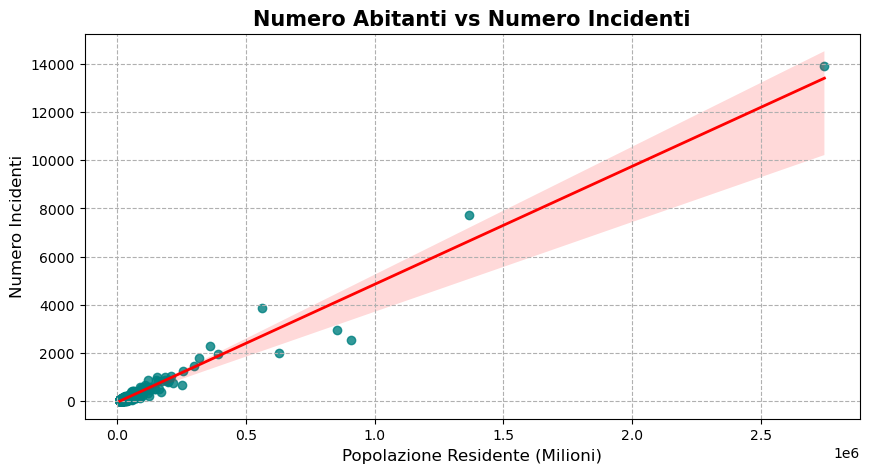

In [25]:
#grafico della regressione

plt.figure(figsize=(10, 5))
sns.regplot(
    data=clean_pivot, 
    x="Popolazione_residente",
    y="Incidenti",
    scatter_kws={"color":"teal"},
    line_kws={"color":"red", "linewidth": 2}
)

plt.title("Numero Abitanti vs Numero Incidenti", fontsize=15, fontweight="bold")
plt.xlabel("Popolazione Residente (Milioni)", fontsize=12)
plt.ylabel("Numero Incidenti", fontsize=12)
plt.grid(True, linestyle="--")
plt.show()

In [26]:
clean_pivot[["Popolazione_residente", "Incidenti"]].describe()
#Controllo la deviazione standard delle colonne - noto che la popolazione ha una deviazione standard molto più alta rispetto a quella degli incidenti

Tipo_dato,Popolazione_residente,Incidenti
count,1.202000e+03,1202.000000
mean,3.409033e+04,117.050749
std,1.023495e+05,511.334072
min,1.000400e+04,1.000000
25%,1.284825e+04,26.000000
50%,1.756850e+04,44.000000
75%,3.021000e+04,85.000000
max,2.747290e+06,13924.000000


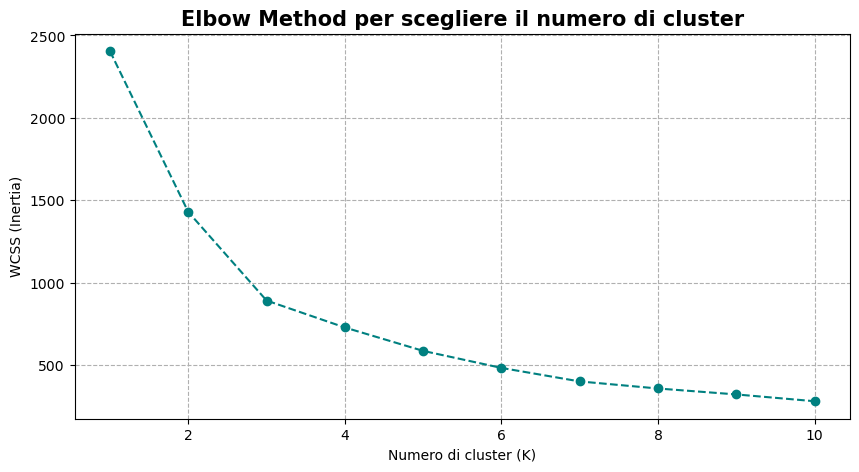

In [27]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Rapporto incidenti ogni 1k abitanti e incidenti/kmq)
X = clean_pivot[["Accidents_per_1k_residents", "Accidents_per_kmsq"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Iterazioni e inerzia (Elbow Method)
wcss=[]
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

#Genero il grafico
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method per scegliere il numero di cluster', fontsize=15, fontweight='bold')
plt.xlabel('Numero di cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, linestyle="--")
plt.show()

In [28]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clean_pivot["Cluster"] = kmeans_final.fit_predict(X_scaled)

#Controllo i cluster
print(clean_pivot["Cluster"].value_counts())

Cluster
1    768
2    368
0     66
Name: count, dtype: int64


In [29]:
cluster_summary = clean_pivot.groupby("Cluster")[["Accidents_per_1k_residents", "Accidents_per_kmsq"]].mean().round(2) #Raggruppo per cluster e faccio la media dei KPI che mi interessano
print(cluster_summary)

Tipo_dato  Accidents_per_1k_residents  Accidents_per_kmsq
Cluster                                                  
0                                4.28               13.64
1                                1.89                1.39
2                                3.89                2.44


In [30]:
#Rinomino i cluster sulla base del print nella cella precedente dove ho identificato il cluster di comuni con riscio più alto e più alta densità di incidenti
cluster_names = {
    0: "Alto rischio / Intensità",
    1: "Basso rischio / Intensità",
    2: "Medio rischio / Intensità"
}

clean_pivot["Nome_Cluster"] = clean_pivot["Cluster"].map(cluster_names)

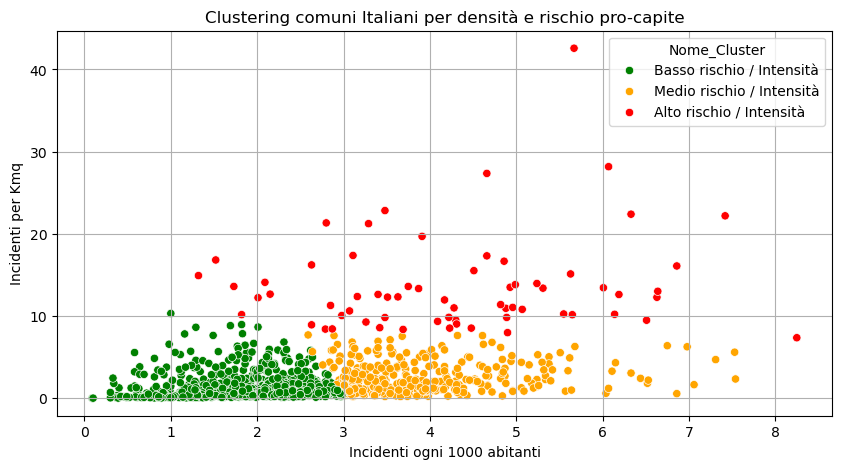

In [31]:
#Grafico del clustering

colors = {
    "Alto rischio / Intensità": "red",
    "Medio rischio / Intensità": "orange",
    "Basso rischio / Intensità": "green"
}

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=clean_pivot, 
    x="Accidents_per_1k_residents", 
    y="Accidents_per_kmsq", 
    hue="Nome_Cluster",
    palette=colors
)

plt.title("Clustering comuni Italiani per densità e rischio pro-capite")
plt.xlabel("Incidenti ogni 1000 abitanti")
plt.ylabel("Incidenti per Kmq")
plt.grid(True)
plt.show()

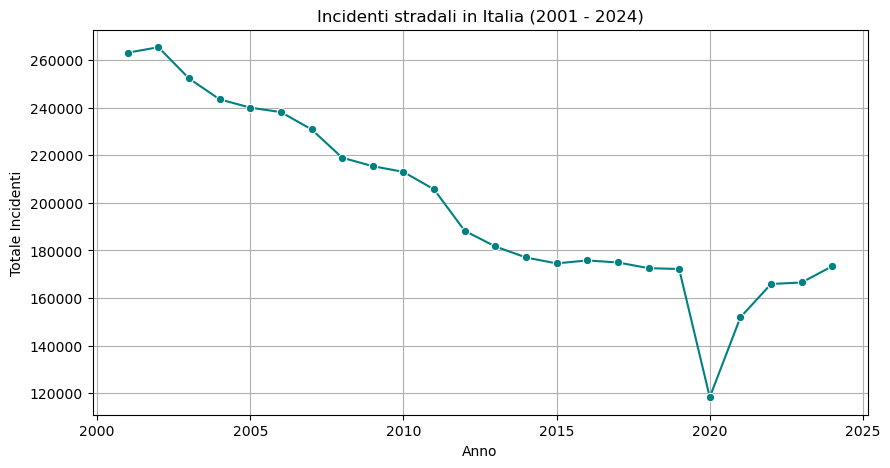

In [32]:
#Analizzo l'andamento del numero di incidenti dal 2001 al 2024

incidents_data = raw_df[raw_df["DATA_TYPE"] == "ROADACC"]

Historic_trend_incidents = incidents_data.groupby("TIME_PERIOD")["OBS_VALUE"].sum().reset_index()
Historic_trend_incidents.columns = ["Anno", "Totale_Incidenti"]

# Grafico
plt.figure(figsize=(10, 5))
sns.lineplot(data=Historic_trend_incidents, x="Anno", y="Totale_Incidenti", marker="o", color="teal")
plt.title("Incidenti stradali in Italia (2001 - 2024)")
plt.xlabel("Anno")
plt.ylabel("Totale Incidenti")
plt.grid(True)
plt.show()

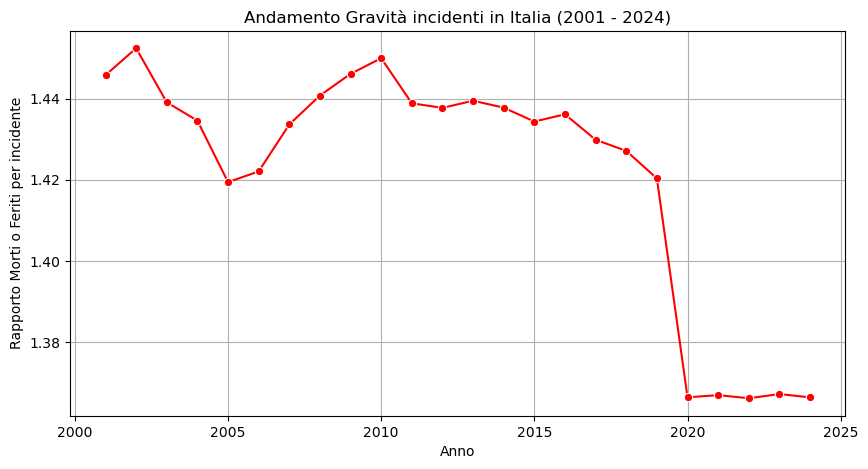

In [33]:
#Recupero anche i dati dei morti e feriti (KILLINJ) dal dataset totale
killinj_data = raw_df[raw_df["DATA_TYPE"] == "KILLINJ"]
killinj_trend = killinj_data.groupby("TIME_PERIOD")["OBS_VALUE"].sum().reset_index()

#Metto i morti nel dataframe precedente e calcolo l'indice di gravità degli incidenti
Historic_trend_incidents["Totale_Morti_Feriti"] = killinj_trend["OBS_VALUE"]
Historic_trend_incidents["Indice_Gravita"] = Historic_trend_incidents["Totale_Morti_Feriti"] / Historic_trend_incidents["Totale_Incidenti"]

#Grafico
plt.figure(figsize=(10, 5))
sns.lineplot(data=Historic_trend_incidents, x="Anno", y="Indice_Gravita", marker="o", color="red")
plt.title("Andamento Gravità incidenti in Italia (2001 - 2024)")
plt.xlabel("Anno")
plt.ylabel("Rapporto Morti o Feriti per incidente")
plt.grid(True)
plt.show()

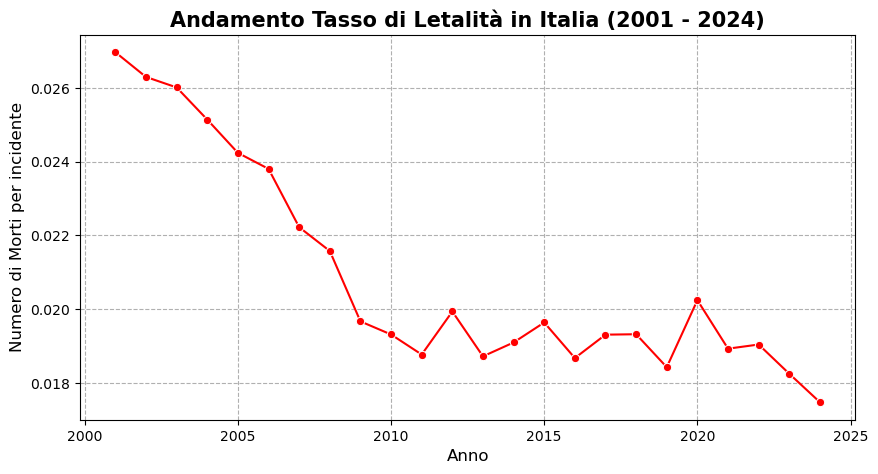

In [34]:
#Faccio la stessa cosa per vedere il trend della letalità negli incidenti
deaths_data = raw_df[(raw_df["DATA_TYPE"] == "KILLINJ") & (raw_df["RESULT"] == "M")]
deaths_trend = deaths_data.groupby("TIME_PERIOD")["OBS_VALUE"].sum().reset_index()
deaths_trend.columns = ["Anno", "Totale_Morti"]

deaths_trend = deaths_trend.sort_values("Anno")
Historic_trend_incidents = Historic_trend_incidents.sort_values("Anno")

Historic_trend_incidents["Totale_Morti"] = deaths_trend["Totale_Morti"]

# Calcolo il Tasso di letalità (Morti / totale incidenti)
Historic_trend_incidents["Tasso_Letalita"] = Historic_trend_incidents["Totale_Morti"] / Historic_trend_incidents["Totale_Incidenti"]

# Grafico
plt.figure(figsize=(10, 5))
sns.lineplot(data=Historic_trend_incidents, x="Anno", y="Tasso_Letalita", marker="o", color="red")
plt.title("Andamento Tasso di Letalità in Italia (2001 - 2024)", fontsize=15, fontweight="bold")
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Numero di Morti per incidente", fontsize=12)
plt.grid(True, linestyle="--")
plt.show()

In [35]:
#Esporto il dataset finale per usarlo su PowerBI
clean_pivot.to_csv("Accidents_analysis_2024.csv", index=False)
print("File salvato")

File salvato
